In [2]:
import pandas as pd

wine = pd.read_csv('../dataset/wine_quality.csv')
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
wine.shape

(55, 12)

In [26]:
input_shape = [11]


### Define the model


In [34]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks


early_stopping = callbacks.EarlyStopping(
    min_delta = 0.001,  # Minimum change to qualify as an improvement
    patience = 20,      # Stop after 20 epochs with no improvement
    restore_best_weights = True
)

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=input_shape),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1)
])      

c:\Users\META\OneDrive\Desktop\kaggle-deep-learning-notes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### We can add activation layers like this (without defining in the same dense layer definiton)

In [27]:
model = keras.Sequential([
    layers.Dense(512, input_shape=input_shape),
    layers.Activation('relu'),
    layers.Dense(512),
    layers.Activation('relu'),
    layers.Dense(512),
    layers.Activation('relu'),
    layers.Dense(1)
])

c:\Users\META\OneDrive\Desktop\kaggle-deep-learning-notes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


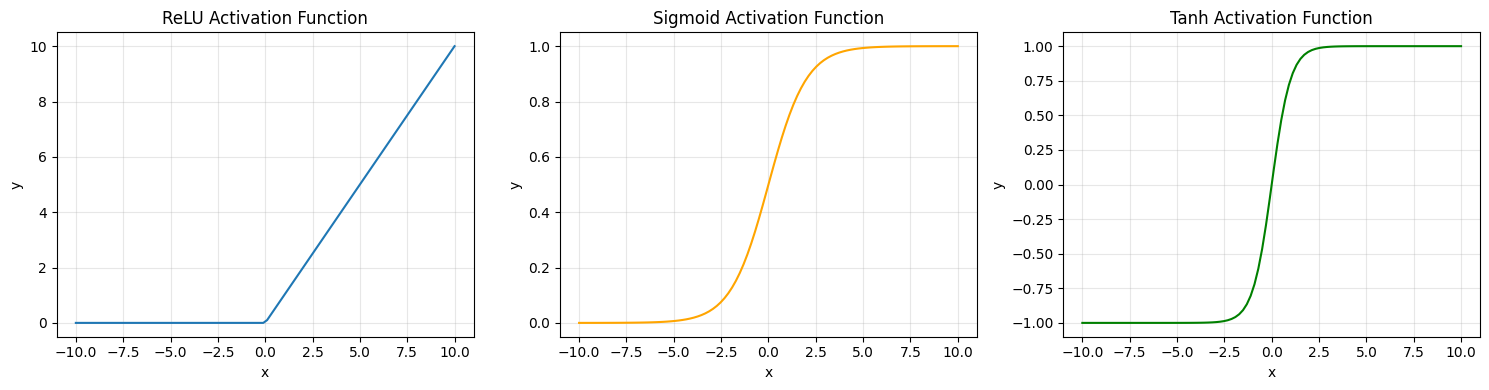

In [21]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Create three activation layers
activation_relu = layers.Activation('relu')
activation_sigmoid = layers.Activation('sigmoid')
activation_tanh = layers.Activation('tanh')

# Generate x values
x = tf.linspace(-10, 10, 100)

# Apply each activation function
y_relu = activation_relu(x)
y_sigmoid = activation_sigmoid(x)
y_tanh = activation_tanh(x)

# Create side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot ReLU
axes[0].plot(x, y_relu)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('ReLU Activation Function')
axes[0].grid(True, alpha=0.3)

# Plot Sigmoid
axes[1].plot(x, y_sigmoid, color='orange')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Sigmoid Activation Function')
axes[1].grid(True, alpha=0.3)

# Plot Tanh
axes[2].plot(x, y_tanh, color='green')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Tanh Activation Function')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
model.compile(
    optimizer='adam',
    loss='mae'
)


### Prepare the data for training

In [23]:
# Split features and target
# Assuming the target column is 'quality' and we'll use 11 features
X = wine.drop('quality', axis=1).iloc[:, :11]  # First 11 features
y = wine['quality']

In [24]:
# Split into training and validation sets
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=30,
    epochs=100,
    callbacks=[early_stopping],
    # verbose=0 
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.4658 - val_loss: 0.6776
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.4841 - val_loss: 0.5645
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.4803 - val_loss: 0.8766
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.7056 - val_loss: 0.4404
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.4651 - val_loss: 0.4391
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.4399 - val_loss: 0.5795
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.4406 - val_loss: 0.4613
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.4807 - val_loss: 0.5503
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.5387 - val_loss: 0.4119
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.4774 - val_loss: 0.3753
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.3796 - val_loss: 0.3608
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.3622 - val

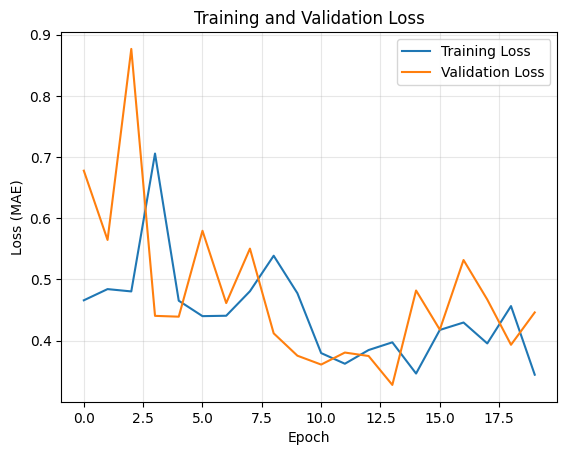

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)
history_df['loss'].plot(label='Training Loss')
history_df['val_loss'].plot(label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()